# Which assistant acts matter, what elicits them, and does the simulator reproduce it

Three questions in order, because each motivates the next.

**A. Which assistant acts predict human transfer?** Two do, in opposite directions.
Measured on humans; this is the motivation for everything else.

**B. What participant behaviour elicits those acts?** Also on humans. This is what a
training intervention would have to change.

**C. Does the simulator reproduce B?** If it does, the simulator can scale up n and run
manipulations that are impractical on people.

### The claim being built

If Board Report helps, and some participant act summons it, then teaching participants
that act should improve transfer. That is the human intervention this is groundwork for.

### Scope

Othello is the primary study. Connect Four is reported alongside but its interaction was
not mandated — participants were free to consult or not, so it carries much thinner
conversation signal (2.7 turns/participant against Othello's 5.6). Treat CF as a
secondary check, not a replication requirement.

### What this does NOT establish

Every association here is **observational**. The participant's act is not randomised, so
an elicitation effect is not a causal effect. And forcing the act does not reproduce it:
in the simulator's `gate-require_kdq` arm the act was classifier-enforced and the
KDQ -> Board Report link collapsed from 86% to 47% per turn. Surface form is not the
construct. A replay design — fixed board, matched question triples differing only in act
— is what would make section B causal.

## 0. Setup

In [44]:
import glob, itertools, json, os, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)

CITRUS = Path("/Users/siyanli/Documents/CITRUS")
SIM_GLOB = "test_agentic_run__human_style*"          # run from bad_user_sim/

# All six participant acts that occur. Metacomment matters: it is the strongest
# positive elicitor of Board Report in Othello, and omitting it makes the model
# report no positive elicitor at all.
PACTS = ["Knowledge Deficit Question", "Solution Request", "Think Aloud",
         "Common Ground Question", "Conversational Acknowledgment", "Metacomment"]
SHORT = {"Knowledge Deficit Question": "KDQ", "Solution Request": "SolReq",
         "Think Aloud": "ThinkAloud", "Common Ground Question": "CGQ",
         "Conversational Acknowledgment": "ConvAck", "Metacomment": "Metacomment"}
AACTS = ["Board Report", "Move Verdict"]

FIELD_A = "annotation_assistant_fine"
FIELD_P = "annotation_user"

# --- assistant scheme revision -------------------------------------------------
# The assistant codes are the AutoTutor tutor moves with Direct Instruction
# fine-grained (Board Report / Local Justification / Worked Line / General Principle);
# Move Verdict is Provide Correct Answer 1:1.
#
# Revision: the three affective codes each fell below any reporting threshold on their
# own (Positive .42, Negative .46, Neutral .34) with large seat splits -- sonnet called
# Positive Feedback at 18% against llama's 7%. Collapsed to one. Dropped: Comprehension
# Gauging Question (0 uses in 1052 turns) and Paraphrase (0.5% prevalence, kappa .09).
#
# Applied to EACH SEAT before the majority vote, not to `final` after it: if gpt says
# Positive and sonnet says Neutral, neither reaches majority at fine grain but both
# agree that feedback occurred.
SEATS = ["gpt", "llama", "sonnet"]
COLLAPSE = {"Positive Feedback": "Feedback", "Negative Feedback": "Feedback",
            "Neutral Feedback": "Feedback"}
DROP = {"Comprehension Gauging Question", "Paraphrase"}

# Assistant codes clearing kappa .6 on the revised scheme (C1). Feedback and Hint do
# not; they stay in the data but should not carry a reported claim.
RELIABLE = {"Move Verdict", "Prompt", "Board Report", "General Principle",
            "Worked Line", "Local Justification"}


def remap(labels):
    return {COLLAPSE.get(c, c) for c in labels if c not in DROP}


def revote(rec, min_votes=2):
    '''Re-derive the panel label under the revised scheme.

    Falls back to the stored `final` when a seat is missing. Reproduces `final` exactly
    on 100% of 3-seat turns when remap() is the identity.
    '''
    per = {k: v for k, v in (rec.get("per_model") or {}).items() if v is not None}
    if len(per) < len(SEATS):
        return remap(rec.get("final") or []), len(per)
    cnt = Counter()
    for s in SEATS:
        cnt.update(remap(per[s]))
    return {c for c, n in cnt.items() if n >= min_votes}, len(per)

In [45]:
# --- human studies -------------------------------------------------------------
# outcome     transfer measure the paper reports (unassisted rounds)
# gate_*      PRE-treatment: the screening move, submitted before the first user turn
# assisted    the AI round's own margin -- POST-treatment, kept only to demonstrate
#             over-control in A3. Never use it as a covariate.
def _oth_margin(d, puzzles):
    tot = 0
    for pz in puzzles:
        f = d / f"oth_score_{pz}.json"
        if not f.exists():
            return None
        v = json.load(open(f)).get("final_margin")
        if v is None:
            return None
        tot += v
    return float(tot)


def _cf_score(d, name):
    f = d / name
    if not f.exists():
        return None
    v = json.load(open(f)).get("score")
    return None if v is None else float(v)


HUMAN = {
    "othello": dict(
        root=CITRUS / "game_user_study_phase_othello/recordings-download",
        ann="annotated_conversation_poc20260727.jsonl",
        gate="gate_poc20260727.json",
        outcome=lambda d: _oth_margin(d, ["pb220260706", "pbg20260726"]),
        assisted=lambda d: _oth_margin(d, ["poc20260727"]),
        outcome_label="solo margin sum, rounds 1-2 (ceiling +16)"),
    "connect_four": dict(
        root=CITRUS / "game_user_study_phase_1/recordings-download",
        ann="annotated_conversation_p15.jsonl",
        gate="gate_p15.json",
        outcome=lambda d: _cf_score(d, "cf_score_pw4p6.json"),
        assisted=lambda d: _cf_score(d, "cf_score_p15.json"),
        outcome_label="transfer optimal moves, round 1 (0-3)"),
}


def load_human_turns(game):
    '''One row per assistant turn carrying both annotation layers. Cluster = pid.'''
    cfg = HUMAN[game]
    rows = []
    for d in sorted(cfg["root"].iterdir()):
        f = d / cfg["ann"]
        if not d.is_dir() or not f.exists():
            continue
        for line in open(f):
            if not line.strip():
                continue
            t = json.loads(line)
            pu, aa = t.get(FIELD_P), t.get(FIELD_A)
            if not pu or not aa or not (t.get("assistant") or "").strip():
                continue
            asst, n_seats = revote(aa)
            rows.append(dict(game=game, pid=d.name, pu=set(pu.get("final") or []),
                             asst=asst, n_seats=n_seats))
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    for p in PACTS:
        df[SHORT[p]] = df.pu.apply(lambda s, p=p: int(p in s))
    return df


def load_human_participants(game):
    '''Per participant: assistant-act share, outcome, pre-treatment gate, n turns.

    Act share = 100 * (assistant turns bearing the act) / (assistant turns), matching
    shares() in human_othello_assistant.py so numbers stay comparable to what has
    already been reported.
    '''
    cfg = HUMAN[game]
    rows = []
    for d in sorted(cfg["root"].iterdir()):
        f = d / cfg["ann"]
        if not d.is_dir() or not f.exists():
            continue
        acts, n = Counter(), 0
        for line in open(f):
            if not line.strip():
                continue
            aa = json.loads(line).get(FIELD_A)
            if not aa:
                continue
            n += 1
            lab, _ = revote(aa)
            acts.update(lab)
        if not n:
            continue
        g = {}
        gf = d / cfg["gate"]
        if gf.exists():
            j = json.load(open(gf))
            g = dict(gate_opt=float(j.get("first_move_optimal") or 0),
                     gate_conf=float(j["confidence"]) if j.get("confidence") is not None
                     else np.nan)
        row = dict(game=game, pid=d.name, n_turns=n, outcome=cfg["outcome"](d),
                   assisted=cfg["assisted"](d), **g)
        for a in acts:
            row[a] = 100.0 * acts[a] / n
        rows.append(row)
    df = pd.DataFrame(rows)
    meta = {"game", "pid", "n_turns", "outcome", "assisted", "gate_opt", "gate_conf"}
    act_cols = [c for c in df.columns if c not in meta]
    df[act_cols] = df[act_cols].fillna(0.0)
    return df

## A. Which assistant acts predict human transfer

| study | outcome | pre-treatment covariate |
|---|---|---|
| Othello | `final_margin` summed over solo rounds 1-2, ceiling +16 | gate move: `first_move_optimal`, `confidence` |
| Connect Four | optimal-move count on `w4p6`, round 1, 0-3 | same |

The AI round is `round=0, ai=True` — the round the conversation happens in. Its margin is
therefore **downstream** of the assistant acts and must not be used as a control; A3
shows what happens when you do.

In [46]:
parts = {g: load_human_participants(g) for g in HUMAN}
for g, d in parts.items():
    if d.empty:
        print(f"{g:<14} no fine-annotated conversations yet"); continue
    gr = d.dropna(subset=["outcome"])
    print(f"{g:<14} {len(d):>4} with conversation | {len(gr):>4} graded | outcome "
          f"{gr.outcome.mean():+.2f} sd {gr.outcome.std():.2f} | "
          f"turns/participant {d.n_turns.mean():.1f}")

othello         120 with conversation |  112 graded | outcome -14.13 sd 11.88 | turns/participant 5.6
connect_four    147 with conversation |  141 graded | outcome +1.58 sd 0.93 | turns/participant 2.7


### A2. Act share vs transfer

Spearman between each assistant act's share of a participant's turns and their transfer
outcome. `prev%` is the share of participants who received the act at least once.

In [47]:
META = {"game", "pid", "n_turns", "outcome", "assisted", "gate_opt", "gate_conf"}

def act_outcome_table(d):
    gr = d.dropna(subset=["outcome"])
    y = gr.outcome.values
    out = []
    for a in sorted(c for c in d.columns if c not in META):
        xs = gr[a].values
        prev = 100 * np.mean(d[a].values > 0)
        if xs.std(ddof=1) < 1e-9:
            out.append((a, prev, 0.0, np.nan, np.nan, "no variance")); continue
        r, p = stats.spearmanr(xs, y)
        out.append((a, prev, xs.std(ddof=1), r, p,
                    "" if a in RELIABLE else "kappa<.6"))
    return pd.DataFrame(out, columns=["act", "prev%", "sd", "rho", "p", "note"])

for g, d in parts.items():
    if d.empty:
        continue
    print(f"\n{'=' * 78}\n{g.upper()}   n={len(d.dropna(subset=['outcome']))} graded   "
          f"{HUMAN[g]['outcome_label']}\n{'=' * 78}")
    print(act_outcome_table(d).sort_values("rho", ascending=False)
          .to_string(index=False, float_format=lambda v: f"{v:7.3f}"))


OTHELLO   n=112 graded   solo margin sum, rounds 1-2 (ceiling +16)
                act   prev%      sd     rho       p     note
       Board Report  83.333  29.396   0.220   0.020         
           Feedback  80.000  22.893   0.207   0.029 kappa<.6
        Worked Line  44.167  15.159   0.128   0.180         
             Prompt  74.167  24.056   0.106   0.265         
  General Principle  95.000  27.316   0.099   0.301         
               Hint  63.333  24.119   0.030   0.752 kappa<.6
Local Justification  97.500  22.712  -0.082   0.392         
       Move Verdict  81.667  31.106  -0.235   0.013         

CONNECT_FOUR   n=141 graded   transfer optimal moves, round 1 (0-3)
                act   prev%      sd     rho       p     note
           Feedback  53.741  34.403   0.118   0.163 kappa<.6
       Board Report  58.503  36.733   0.074   0.381         
        Worked Line  14.966  16.912   0.071   0.400         
Local Justification  91.837  29.506   0.053   0.530         
         

### A3. Do the covariates change anything?

A covariate is a confounder only if it predicts the outcome. Rather than partial
correlations, this is a plain OLS with the act share as predictor, adding covariates one
at a time -- same machinery as the model comparison, so the coefficients and the AIC/BIC
below come from one place.

- **turns** -- a participant who talks more has more chances to receive any act
- **gate** -- the pre-treatment screening move and its confidence rating
- **assisted** -- the AI round's own margin. **Post-treatment.** Included only to show
  the damage: it is caused by the acts (Move Verdict share rho +0.60), so conditioning on
  it removes real signal.

Act share is in percentage points, so a coefficient of 0.08 means 0.08 margin per extra
point of share; the acts range 0-80% across participants, so multiply by ~30 for a
one-SD change.

In [48]:
COVSETS = {
    "act alone":            [],
    "+ turns":              ["n_turns"],
    "+ gate (pre)":         ["gate_opt", "gate_conf"],
    "+ turns + gate":       ["n_turns", "gate_opt", "gate_conf"],
    "+ assisted (POST)":    ["assisted"],
}

def covariate_table(d, act):
    gr = d.dropna(subset=["outcome", "gate_conf", "assisted"])
    y = gr.outcome.values
    out = []
    for name, cov in COVSETS.items():
        X = sm.add_constant(gr[[act] + cov])
        m = sm.OLS(y, X).fit()
        out.append((name, m.params[act], m.bse[act], m.pvalues[act],
                    m.rsquared_adj, m.aic, m.bic))
    t = pd.DataFrame(out, columns=["model", "beta", "se", "p", "adjR2", "AIC", "BIC"])
    t.insert(5, "dAIC", t.AIC - t.AIC.min())
    return t, len(gr)

print("Is each candidate covariate related to the outcome at all?\n")
for g, d in parts.items():
    gr = d.dropna(subset=["outcome", "gate_conf", "assisted"])
    for cv in ["n_turns", "gate_opt", "gate_conf", "assisted"]:
        r, p = stats.spearmanr(gr[cv], gr.outcome)
        tag = "   <- POST-treatment" if cv == "assisted" else ""
        print(f"  {g:<13}{cv:<11} ~ outcome   rho {r:+.3f}  p {p:.3g}{tag}")
    print()

for g, d in parts.items():
    for act in AACTS:
        t, n = covariate_table(d, act)
        print(f"\n{g.upper()} — {act}   (n={n})")
        print(t.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

Is each candidate covariate related to the outcome at all?

  othello      n_turns     ~ outcome   rho +0.070  p 0.461
  othello      gate_opt    ~ outcome   rho +0.059  p 0.537
  othello      gate_conf   ~ outcome   rho +0.124  p 0.194
  othello      assisted    ~ outcome   rho -0.212  p 0.0246   <- POST-treatment

  connect_four n_turns     ~ outcome   rho +0.040  p 0.639
  connect_four gate_opt    ~ outcome   rho +0.115  p 0.175
  connect_four gate_conf   ~ outcome   rho -0.088  p 0.297
  connect_four assisted    ~ outcome   rho +0.067  p 0.432   <- POST-treatment


OTHELLO — Board Report   (n=112)
            model     beta       se        p    adjR2     dAIC      AIC      BIC
        act alone    0.083    0.038    0.029    0.034    0.000  870.320  875.757
          + turns    0.084    0.038    0.031    0.025    1.986  872.306  880.462
     + gate (pre)    0.080    0.039    0.044    0.027    2.734  873.054  883.928
   + turns + gate    0.081    0.040    0.044    0.018    4.694  875

Read the `act alone` row for the effect, and `dAIC` for whether any covariate earns its
degrees of freedom. A covariate that buys nothing costs about 2 AIC points -- the penalty
for its parameter.

## B. What elicits those acts in humans

Turn level. All six participant acts enter together, because they co-occur and a
marginal association confounds them. SEs cluster-robust by participant.

In [49]:
hturns = {g: load_human_turns(g) for g in HUMAN}
for g, d in hturns.items():
    if d.empty:
        print(f"{g:<14} no turns with both layers"); continue
    print(f"\n{g.upper()}  {len(d)} turns, {d.pid.nunique()} participants")
    print(f"  {'participant act':<32}{'turns':>7}{'% of turns':>12}")
    for pa in PACTS:
        n = int(d[SHORT[pa]].sum())
        print(f"  {pa:<32}{n:>7}{100*n/len(d):>11.1f}%")

SEPARATION = (1e-3, 1e3)   # ORs outside this are separation artifacts, not estimates


def elicit_logit(d, target, cluster, extra=()):
    y = d.asst.apply(lambda s: int(target in s))
    if y.nunique() < 2:
        return None
    X = d[[SHORT[p] for p in PACTS]].copy()
    for name, col in extra:
        X[name] = col
    X = sm.add_constant(X)
    m = sm.Logit(y, X).fit(disp=0, cov_type="cluster", cov_kwds={"groups": cluster})
    r = pd.DataFrame({"OR": np.exp(m.params), "p": m.pvalues,
                      "lo": np.exp(m.conf_int()[0]), "hi": np.exp(m.conf_int()[1])})
    r = r[~r.index.str.startswith(("const", "arm_"))]
    # Quasi-complete separation: if an act never co-occurs with the outcome the MLE
    # runs to +/-inf and both OR and p are meaningless. Flag, don't drop.
    r["sep"] = ""
    for k in r.index:
        if not (SEPARATION[0] < r.loc[k, "OR"] < SEPARATION[1]):
            yy = int(((X[k] == 1) & (y == 1)).sum())
            n1 = int((X[k] == 1).sum())
            r.loc[k, "sep"] = f"SEPARATION {yy}/{n1}"
    return r

for target in AACTS:
    print(f"\n{'=' * 76}\nHUMAN elicitation of {target}\n{'=' * 76}")
    for g, d in hturns.items():
        if d.empty:
            continue
        r = elicit_logit(d, target, d.pid)
        if r is None:
            print(f"-- {g}: no variance"); continue
        print(f"-- {g}  (n={len(d)} turns, {d.pid.nunique()} participants)")
        print(r.sort_values("OR", ascending=False)
              .to_string(float_format=lambda v: f"{v:9.3f}"))


OTHELLO  667 turns, 120 participants
  participant act                   turns  % of turns
  Knowledge Deficit Question          112       16.8%
  Solution Request                    197       29.5%
  Think Aloud                         206       30.9%
  Common Ground Question              245       36.7%
  Conversational Acknowledgment       119       17.8%
  Metacomment                          71       10.6%

CONNECT_FOUR  386 turns, 141 participants
  participant act                   turns  % of turns
  Knowledge Deficit Question           31        8.0%
  Solution Request                    147       38.1%
  Think Aloud                         138       35.8%
  Common Ground Question              146       37.8%
  Conversational Acknowledgment        51       13.2%
  Metacomment                          18        4.7%

HUMAN elicitation of Board Report
-- othello  (n=667 turns, 120 participants)
                   OR         p        lo        hi sep
Metacomment     2.849     0.

### B1b. What does each participant act elicit?

Sections B and G focus on Board Report and Move Verdict because those are the two acts
with an observational link to transfer. But it is worth seeing the whole row for the acts
that matter to the intervention -- particularly **Think Aloud**, which predicts transfer
more strongly than anything else (section F).

The result is sharper than a null. Think Aloud clearly reshapes the assistant -- it
elicits Prompt, Worked Line, Hint and Feedback, and suppresses Move Verdict -- but is flat
on **Board Report**, the only assistant act with a transfer correlation. So its effect on
learning cannot be running through the tutor, and that conclusion rests on a pattern of
significant effects rather than on failing to detect anything.

In [50]:
FOCUS_ACTS = ["Think Aloud", "Solution Request", "Knowledge Deficit Question"]
ALL_ASSISTANT = ["Board Report", "Move Verdict", "General Principle",
                 "Local Justification", "Worked Line", "Prompt", "Hint", "Feedback"]

for g, d in hturns.items():
    if d.empty:
        continue
    print(f"\n{'=' * 78}\n{g.upper()} — odds ratio for each assistant act, "
          f"adjusted for all participant acts\n{'=' * 78}")
    print(f"{'assistant act':<24}" + "".join(f"{SHORT[a]:>22}" for a in FOCUS_ACTS))
    for aa in ALL_ASSISTANT:
        y = d.asst.apply(lambda s, t=aa: int(t in s))
        if y.nunique() < 2:
            continue
        X = sm.add_constant(d[[SHORT[p] for p in PACTS]])
        m = sm.Logit(y, X).fit(disp=0, cov_type="cluster",
                               cov_kwds={"groups": d.pid})
        line = f"{aa:<24}"
        for pa in FOCUS_ACTS:
            k = SHORT[pa]
            o, pv = np.exp(m.params[k]), m.pvalues[k]
            star = "***" if pv < .001 else "**" if pv < .01 else "*" if pv < .05 else ""
            line += f"{o:>17.2f} {star:<4}"
        print(line)
    print("\n  Think Aloud is NOT inert: it elicits Prompt, Worked Line, Hint and")
    print("  Feedback, and suppresses Move Verdict. It is flat specifically on Board")
    print("  Report -- the one assistant act that predicts transfer. So its transfer")
    print("  effect cannot run through the tutor, even though it visibly changes the")
    print("  tutor. Note Hint (kappa .38) and Feedback (.47) are below threshold;")
    print("  Prompt (.74), Worked Line (.66) and Move Verdict (.86) are not.")


OTHELLO — odds ratio for each assistant act, adjusted for all participant acts
assistant act                       ThinkAloud                SolReq                   KDQ
Board Report                         0.98                  0.17 ***              1.55     
Move Verdict                         0.72                 33.51 ***              0.11 *** 
General Principle                    1.00                  0.56 *                3.86 *** 
Local Justification                  1.71                  7.71 ***              0.64     
Worked Line                          2.26 **               0.82                  0.63     
Prompt                               2.13 ***              0.15 ***              0.43 **  
Hint                                 1.68 *                0.16 ***              0.42 *   
Feedback                             2.54 ***              0.28 ***              0.66     

  Think Aloud is NOT inert: it elicits Prompt, Worked Line, Hint and
  Feedback, and suppresses Move

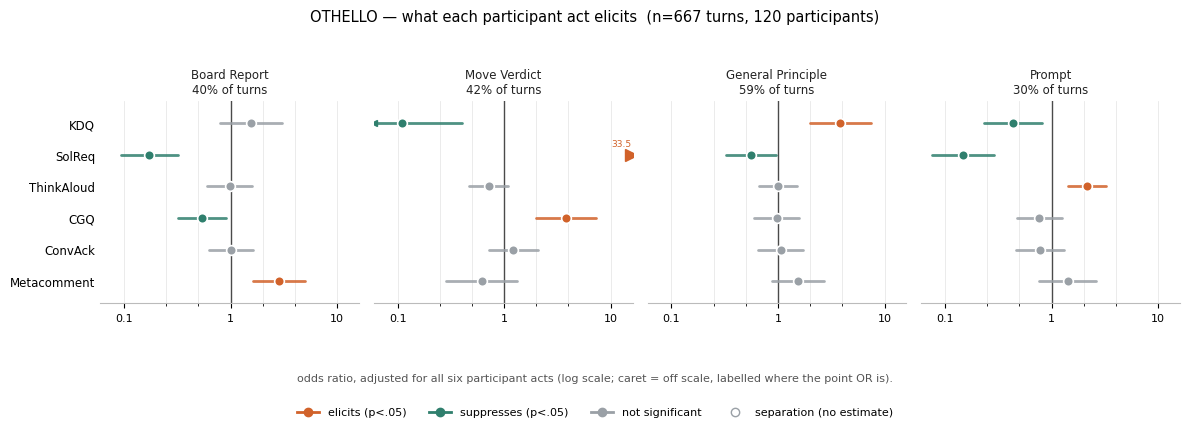

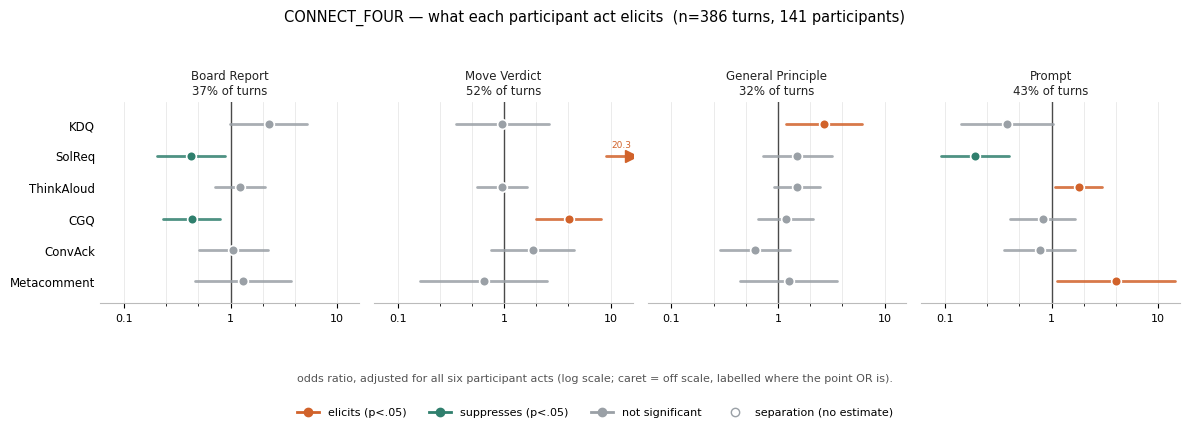

In [51]:
# --- B1c. The whole elicitation matrix, drawn -----------------------------------
# Same model as B1b -- one logit per assistant act with all six participant acts
# entered together, SEs cluster-robust by participant. The table above prints three
# of its columns; this draws all six, so a flat row (Think Aloud on Board Report)
# is visible next to the rows that are not flat.
#
# Position relative to the OR=1 line carries the direction, so colour is redundant
# with it and only marks significance. CIs are wide at this n by construction; a
# caret means the interval runs past the axis, not that it ends there.
#
# Panels are restricted to the reportable assistant acts -- the four that clear
# kappa .60 on every source (Move Verdict .85, Prompt .81, General Principle .68,
# Board Report .67 pooled). Hint clears it on both human sets but fails on the
# simulator, so it stays out for comparability with G; Feedback (.44) is out
# everywhere; Local Justification and Worked Line are reliable only after merging
# to Move Explanation, which then fires on 84% of turns and cannot discriminate.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PANEL_ACTS = ["Board Report", "Move Verdict", "General Principle", "Prompt"]
XLIM = (0.06, 16.0)          # log axis; wider CIs are drawn clipped with a caret
C_UP, C_DOWN, C_NS = "#d1622a", "#2f7f6d", "#9aa0a6"


def elicit_matrix(d):
    '''One row per (assistant act, participant act): OR, CI, p, separation flag.'''
    rows = []
    for aa in PANEL_ACTS:
        y = d.asst.apply(lambda s, t=aa: int(t in s))
        if y.nunique() < 2:
            continue
        X = sm.add_constant(d[[SHORT[p] for p in PACTS]])
        m = sm.Logit(y, X).fit(disp=0, cov_type="cluster",
                               cov_kwds={"groups": d.pid})
        ci = np.exp(m.conf_int())
        for pa in PACTS:
            k = SHORT[pa]
            orr = float(np.exp(m.params[k]))
            rows.append(dict(
                asst=aa, pact=k, OR=orr, lo=float(ci.loc[k, 0]),
                hi=float(ci.loc[k, 1]), p=float(m.pvalues[k]),
                # Quasi-complete separation: the MLE ran to +/-inf, so the OR and its
                # CI are artifacts. Flagged and drawn hollow rather than dropped.
                sep=not (SEPARATION[0] < orr < SEPARATION[1]),
                co=int(((X[k] == 1) & (y == 1)).sum()), n1=int((X[k] == 1).sum()),
                n_asst=int(y.sum())))
    return pd.DataFrame(rows)


def plot_elicitation(d, game):
    mat = elicit_matrix(d)
    acts = [a for a in PANEL_ACTS if a in set(mat.asst)]
    ypos = {SHORT[p]: len(PACTS) - 1 - i for i, p in enumerate(PACTS)}   # top-down

    fig, axes = plt.subplots(1, len(acts), figsize=(2.6 * len(acts) + 1.6, 3.4),
                             sharey=True)
    axes = np.atleast_1d(axes)
    for ax, aa in zip(axes, acts):
        sub = mat[mat.asst == aa]
        ax.axvline(1, color="#4a4a4a", lw=1, zorder=1)
        for _, r in sub.iterrows():
            yy = ypos[r.pact]
            col = C_NS if (r.p >= .05 or r.sep) else (C_UP if r.OR > 1 else C_DOWN)
            if r.sep:
                # No estimate to draw: park it at the edge it ran off to.
                x = XLIM[1] * 0.92 if r.OR > 1 else XLIM[0] * 1.08
                ax.plot([x], [yy], marker="o", ms=6, mfc="white", mec=col, mew=1.4,
                        zorder=3)
                ax.text(x, yy + 0.3, f"sep {r.co}/{r.n1}", fontsize=6, color=col,
                        ha="center")
                continue
            # Clamp to the axis, then say so. A caret is drawn only for the bound
            # that actually leaves the axis, and an estimate whose point OR is off
            # scale is labelled with its value instead of a dot mashed on the edge.
            lo, hi = float(np.clip(r.lo, *XLIM)), float(np.clip(r.hi, *XLIM))
            if hi > lo:
                ax.plot([lo, hi], [yy, yy], color=col, lw=2,
                        solid_capstyle="round", alpha=.85, zorder=2)
            if r.lo < XLIM[0]:
                ax.plot([XLIM[0]], [yy], marker="<", ms=5, color=col, zorder=3)
            if r.hi > XLIM[1]:
                ax.plot([XLIM[1]], [yy], marker=">", ms=5, color=col, zorder=3)
            if XLIM[0] < r.OR < XLIM[1]:
                ax.plot([r.OR], [yy], marker="o", ms=7, color=col, mec="white",
                        mew=1.2, zorder=4)
            else:
                off_hi = r.OR >= XLIM[1]
                x = XLIM[1] * 0.97 if off_hi else XLIM[0] * 1.03
                ax.plot([x], [yy], marker=">" if off_hi else "<", ms=8, color=col,
                        zorder=4)
                ax.text(x, yy + 0.28, f"{r.OR:.3g}", fontsize=6.5, color=col,
                        ha="right" if off_hi else "left")
        n_asst = int(sub.n_asst.iloc[0])
        dagger = "" if aa in RELIABLE else " †"
        ax.set_title(f"{aa}{dagger}\n{100 * n_asst / len(d):.0f}% of turns",
                     fontsize=8.5, color="#222" if aa in RELIABLE else "#777")
        ax.set_xscale("log")
        ax.set_xlim(*XLIM)
        ax.set_xticks([0.1, 1, 10])
        ax.set_xticklabels(["0.1", "1", "10"], fontsize=8)
        ax.set_xticks([0.25, 0.5, 2, 4], minor=True)
        ax.set_xticklabels([], minor=True)
        ax.tick_params(axis="y", length=0)
        ax.set_ylim(-0.7, len(PACTS) - 0.3)
        ax.grid(axis="x", color="#e8e8e8", lw=.6, which="both", zorder=0)
        ax.set_axisbelow(True)
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)
        ax.spines["bottom"].set_color("#bbb")

    axes[0].set_yticks([ypos[SHORT[p]] for p in PACTS])
    axes[0].set_yticklabels([SHORT[p] for p in PACTS], fontsize=8.5)
    fig.suptitle(f"{game.upper()} — what each participant act elicits  "
                 f"(n={len(d)} turns, {d.pid.nunique()} participants)",
                 fontsize=10.5, y=1.04)
    dag_note = " † = kappa<.6." if any(a not in RELIABLE for a in acts) else ""
    fig.supxlabel("odds ratio, adjusted for all six participant acts (log scale; "
                  f"caret = off scale, labelled where the point OR is).{dag_note}",
                  fontsize=8, color="#555", y=-0.06)
    fig.legend(handles=[
        Line2D([], [], color=C_UP, marker="o", lw=2, label="elicits (p<.05)"),
        Line2D([], [], color=C_DOWN, marker="o", lw=2, label="suppresses (p<.05)"),
        Line2D([], [], color=C_NS, marker="o", lw=2, label="not significant"),
        Line2D([], [], color=C_NS, marker="o", lw=0, mfc="white", mec=C_NS,
               label="separation (no estimate)")],
        loc="lower center", ncol=4, frameon=False, fontsize=8,
        bbox_to_anchor=(0.5, -0.19))
    plt.tight_layout()
    plt.show()
    return mat


elic_mats = {}
for g, d in hturns.items():
    if d.empty:
        continue
    elic_mats[g] = plot_elicitation(d, g)


### B2. Question orientation

**On Knowledge Deficit Question.** Its odds ratio for Board Report is 1.59, CI
[0.82, 3.08], p=.17 on 108 turns -- a positive point estimate that is not distinguishable
from 1 at this n. Saying it "does not affect Board Report" would be too strong; the right
statement is that its independent contribution is not detectable, and that what
association exists is largely orientation in disguise. KDQ turns are retrospective 33% of
the time against 10% for other turns, and adding orientation to the model drops KDQ from
1.59 to 1.14 while RETRO comes in at 3.14. Orientation is the better-specified variable,
not a competing one.

The act labels do not separate the turns that draw a Board Report from those that draw a
Move Verdict. Both of these are Common Ground Question and get opposite replies:

```
"was it a bad move to choose a1? If so, why?"   -> Board Report
"is a1 the best move?"                          -> no Board Report
```

What separates them is what the utterance is oriented toward — **what already happened**
vs **what to do next**. That cuts across the AutoTutor acts rather than subdividing them,
so it needs its own layer.

`question_orientation.combined_orient` is deterministic — a lexical regex intersected
with NLTK POS features (past tense / modality / bare move proposal). No LLM at inference.
It is deliberately **high precision, low recall**: it classifies ~33% of turns and
abstains on the rest, and the abstained turns sit at the base rate, which is what
abstention rather than misclassification looks like. Exclude them; they are not a third
category.

A `STATE` category (present-tense queries about the current position) is computed by the
POS classifier but **should not be reported** — OR 1.25, p .61, n=38. It did not pan out.

In [52]:
try:
    import question_orientation as qo
    HAVE_QO = True
except ImportError as e:
    print(f"question_orientation unavailable ({e}); pip install nltk"); HAVE_QO = False


def add_orientation(df, texts):
    df = df.copy()
    lab = [qo.combined_orient(t) for t in texts]
    df["RETRO"] = [int("RETRO" in x) for x in lab]
    df["PROSP"] = [int("PROSP" in x) for x in lab]
    return df


def load_human_turns_text(game):
    '''Same rows as load_human_turns, plus the raw utterance for orientation.'''
    cfg = HUMAN[game]
    rows, texts = [], []
    for d in sorted(cfg["root"].iterdir()):
        f = d / cfg["ann"]
        if not d.is_dir() or not f.exists():
            continue
        for line in open(f):
            if not line.strip():
                continue
            t = json.loads(line)
            pu, aa = t.get(FIELD_P), t.get(FIELD_A)
            u = (t.get("user") or "").strip()
            if not pu or not aa or not u or not (t.get("assistant") or "").strip():
                continue
            asst, n_seats = revote(aa)
            rows.append(dict(game=game, pid=d.name, pu=set(pu.get("final") or []),
                             asst=asst, n_seats=n_seats))
            texts.append(u)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    for p in PACTS:
        df[SHORT[p]] = df.pu.apply(lambda s, p=p: int(p in s))
    return add_orientation(df, texts)

if HAVE_QO:
    ht = {g: load_human_turns_text(g) for g in HUMAN}
    for g, d in ht.items():
        if d.empty:
            continue
        br = d.asst.apply(lambda s: int("Board Report" in s))
        print(f"\n{'=' * 74}\n{g.upper()}   n={len(d)} assistant turns\n{'=' * 74}")
        print("Each cell is the SHARE OF TURNS whose assistant reply contained a Board")
        print("Report. So 0.68 means: of the turns classified retrospective, 68% drew a")
        print("reply that described the position. Compare against the base rate.\n")
        print(f"{'group':<16}{'turns':>7}{'w/ Board Report':>18}{'share':>8}")
        for grp, sel in [("retrospective", d.RETRO == 1), ("prospective", d.PROSP == 1),
                         ("unclassified", (d.RETRO == 0) & (d.PROSP == 0)),
                         ("ALL (base rate)", d.RETRO >= 0)]:
            if sel.sum():
                print(f"{grp:<16}{int(sel.sum()):>7}{int(br[sel].sum()):>18}"
                      f"{br[sel].mean():>8.2f}")
        print("\n  'unclassified' sits at the base rate -- the classifier abstains on")
        print("  those turns rather than mislabelling them, so they are excluded, not")
        print("  treated as a third category.")


OTHELLO   n=667 assistant turns
Each cell is the SHARE OF TURNS whose assistant reply contained a Board
Report. So 0.68 means: of the turns classified retrospective, 68% drew a
reply that described the position. Compare against the base rate.

group             turns   w/ Board Report   share
retrospective        88                60    0.68
prospective         136                28    0.21
unclassified        449               180    0.40
ALL (base rate)     667               265    0.40

  'unclassified' sits at the base rate -- the classifier abstains on
  those turns rather than mislabelling them, so they are excluded, not
  treated as a third category.

CONNECT_FOUR   n=386 assistant turns
Each cell is the SHARE OF TURNS whose assistant reply contained a Board
Report. So 0.68 means: of the turns classified retrospective, 68% drew a
reply that described the position. Compare against the base rate.

group             turns   w/ Board Report   share
retrospective        33          

In [53]:
if HAVE_QO:
    ACTCOLS = [SHORT[p] for p in PACTS]
    for g, d in ht.items():
        if d.empty:
            continue
        print(f"\n{'=' * 74}\n{g.upper()} — does orientation add to the act model?"
              f"\n{'=' * 74}")
        for target in AACTS:
            y = d.asst.apply(lambda s, t=target: int(t in s))
            if y.nunique() < 2:
                continue
            fits = {}
            for lab, cols in [("acts only", ACTCOLS),
                              ("acts + orientation", ACTCOLS + ["RETRO", "PROSP"])]:
                m = sm.Logit(y, sm.add_constant(d[cols])).fit(
                    disp=0, cov_type="cluster", cov_kwds={"groups": d.pid})
                fits[lab] = m
                print(f"  {target:<14} {lab:<20} AIC {m.aic:7.1f}  "
                      f"pseudoR2 {m.prsquared:.3f}")
            m = fits["acts + orientation"]
            ci = m.conf_int()
            print(f"  {'':14} {'':20} {'OR':>8}{'95% CI':>18}{'p':>9}{'turns':>7}")
            for k in ("RETRO", "PROSP"):
                print(f"  {'':14} {k:<20}{np.exp(m.params[k]):>8.2f}"
                      f"   [{np.exp(ci[0][k]):.2f}, {np.exp(ci[1][k]):.2f}]".rjust(18)
                      + f"{m.pvalues[k]:>9.3g}{int(d[k].sum()):>7}")


OTHELLO — does orientation add to the act model?
  Board Report   acts only            AIC   807.9  pseudoR2 0.114
  Board Report   acts + orientation   AIC   787.5  pseudoR2 0.142
                                            OR            95% CI        p  turns
                 RETRO                   3.05   [1.77, 5.27] 6.26e-05     88
                 PROSP                   0.56   [0.33, 0.97]   0.0375    136
  Move Verdict   acts only            AIC   603.2  pseudoR2 0.352
  Move Verdict   acts + orientation   AIC   597.4  pseudoR2 0.363
                                            OR            95% CI        p  turns
                 RETRO                   0.62   [0.25, 1.54]    0.303     88
                 PROSP                   2.00   [1.23, 3.26]  0.00519    136

CONNECT_FOUR — does orientation add to the act model?
  Board Report   acts only            AIC   496.9  pseudoR2 0.053
  Board Report   acts + orientation   AIC   496.8  pseudoR2 0.061
                             

## C. The simulator

Same question, on simulated conversations, for **n** and for manipulations that cannot be
run on people.

`SPONTANEOUS` marks arms with no participant-act manipulation. Everything else is gated,
knocked out, or prompt-encouraged, so its act distribution is engineered — pooled models
carry arm fixed effects and the spontaneous column sits beside them. Where the two
disagree, trust the spontaneous one.

In [54]:
SPONTANEOUS = {"human_style_q5_shared_context"}

def load_sim(arm_glob=SIM_GLOB):
    rows = []
    for fp in sorted(glob.glob(f"{arm_glob}/*/annotated_conversation_*.jsonl")):
        arm, cell = fp.split(os.sep)[0].replace("test_agentic_run__", ""), fp.split(os.sep)[1]
        for line in open(fp):
            if not line.strip():
                continue
            t = json.loads(line)
            pu, aa = t.get(FIELD_P), t.get(FIELD_A)
            if not pu or not aa or not (t.get("assistant") or "").strip():
                continue
            asst, n_seats = revote(aa)
            rows.append(dict(arm=arm, cell=cell, pu=set(pu.get("final") or []),
                             asst=asst, n_seats=n_seats))
    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit("no simulated turns with both layers -- run "
                         "annotate_sim_assistant_fine.py from bad_user_sim/")
    df["spont"] = df.arm.isin(SPONTANEOUS)
    for p in PACTS:
        df[SHORT[p]] = df.pu.apply(lambda s, p=p: int(p in s))
    return df

sim = load_sim()
print(f"{len(sim)} turns | {sim.cell.nunique()} cells | {sim.arm.nunique()} arms | "
      f"spontaneous {sim.spont.sum()} / manipulated {(~sim.spont).sum()}\n")
print(sim.groupby("arm").agg(turns=("arm", "size"), cells=("cell", "nunique")).to_string())

1347 turns | 80 cells | 8 arms | spontaneous 194 / manipulated 1153

                                                  turns  cells
arm                                                           
human_style+no_concept_q_q5_shared_context           99     20
human_style+no_think_aloud_q5_shared_context         99     20
human_style_q5                                      400     80
human_style_q5_gate-concept_q_shared_context         50     10
human_style_q5_gate-require_kdq_shared_context       90     18
human_style_q5_gate-require_think_shared_context     25      5
human_style_q5_shared_context                       194     39
human_style_think_q5                                390     78


### C1. Panel reliability

Fleiss' kappa per code over the three seats, from `per_model` — free, no new calls.
Assistant side before and after the scheme revision, then the participant side. Same
panel across simulator and both human studies, so the three are directly comparable.

In [55]:
def fleiss_binary(counts, k=3):
    '''counts[i] = how many of the k seats applied the code to turn i.'''
    n = len(counts)
    Pi = [(c * (c - 1) + (k - c) * (k - c - 1)) / (k * (k - 1)) for c in counts]
    p1 = sum(counts) / (n * k)
    Pe = p1 ** 2 + (1 - p1) ** 2
    return (np.mean(Pi) - Pe) / (1 - Pe) if Pe < 1 else np.nan


def collect(pattern, field):
    '''Records where all three canonical seats returned.

    A handful of turns fell back to a substitute seat (e.g. gemma for sonnet); those
    are excluded rather than mixed in, since kappa is per-seat.
    '''
    recs, swapped = [], 0
    for fp in sorted(glob.glob(str(pattern))):
        for line in open(fp):
            if not line.strip():
                continue
            aa = json.loads(line).get(field)
            if not aa:
                continue
            per = {k: v for k, v in (aa.get("per_model") or {}).items() if v is not None}
            if set(per) == set(SEATS):
                recs.append(per)
            elif len(per) == len(SEATS):
                swapped += 1
    if swapped:
        print(f"    ({swapped} turn(s) excluded: substitute seat)")
    return recs


def kappa_table(recs, f, label, reliable):
    if not recs:
        print(f"  {label}: no 3-seat turns"); return
    codes = sorted({c for per in recs for s in SEATS for c in f(per[s])})
    print(f"  {label}  (n={len(recs)})")
    out = []
    for c in codes:
        counts = [sum(c in f(per[s]) for s in SEATS) for per in recs]
        prev = 100 * np.mean([n >= 2 for n in counts])
        sp = "/".join(f"{100*np.mean([c in f(per[s]) for per in recs]):.0f}"
                      for s in SEATS)
        out.append((prev, c, fleiss_binary(counts), sp))
    for prev, c, kap, sp in sorted(out, reverse=True):
        flag = "" if (reliable is None or c in reliable or kap >= 0.6) else "  <- below .6"
        print(f"    {c:<32}{prev:>7.1f}{kap:>8.2f}   {sp}{flag}")
    jac = [len(f(per[x]) & f(per[y])) / len(f(per[x]) | f(per[y]))
           for per in recs for x, y in itertools.combinations(SEATS, 2)
           if f(per[x]) | f(per[y])]
    print(f"    mean pairwise Jaccard {np.mean(jac):.3f}\n")

SOURCES = [("SIMULATED", f"{SIM_GLOB}/*/annotated_conversation_*.jsonl")] + \
          [(f"HUMAN {g}", HUMAN[g]["root"] / "*" / HUMAN[g]["ann"]) for g in HUMAN]

print("### ASSISTANT side\n")
for label, pat in SOURCES:
    recs = collect(pat, FIELD_A)
    kappa_table(recs, lambda x: set(x), f"{label} — before revision", RELIABLE)
    kappa_table(recs, remap, f"{label} — after revision", RELIABLE)

print("\n### PARTICIPANT side\n")
for label, pat in SOURCES:
    kappa_table(collect(pat, FIELD_P), lambda x: set(x), label, None)

### ASSISTANT side

  SIMULATED — before revision  (n=1347)
    Local Justification                86.9    0.59   80/90/88
    Move Verdict                       59.0    0.86   58/63/60
    General Principle                  53.5    0.67   58/43/58
    Board Report                       33.8    0.73   29/37/38
    Worked Line                        14.1    0.66   18/15/13
    Neutral Feedback                   12.2    0.34   18/5/18  <- below .6
    Prompt                             11.7    0.74   12/10/13
    Positive Feedback                   9.4    0.42   8/7/18  <- below .6
    Negative Feedback                   8.9    0.46   8/8/14  <- below .6
    Hint                                7.7    0.38   7/16/6  <- below .6
    Paraphrase                          0.5    0.09   3/0/3  <- below .6
    Comprehension Gauging Question      0.0   -0.00   0/0/0  <- below .6
    mean pairwise Jaccard 0.749

  SIMULATED — after revision  (n=1347)
    Local Justification                86.9    

### C2. Simulated elicitation

In [56]:
for target in AACTS:
    spont = elicit_logit(sim[sim.spont], target, sim[sim.spont].cell)
    extra = [(f"arm_{a[:16]}", (sim.arm == a).astype(int))
             for a in sorted(sim.arm.unique())[1:]]
    pool = elicit_logit(sim, target, sim.cell, extra=extra)
    out = pd.concat([spont[["OR", "p"]].add_suffix("_spont"),
                     pool[["OR", "p", "lo", "hi"]].add_suffix("_pooled"),
                     pool[["sep"]]], axis=1)
    print(f"\n{'=' * 88}\nSIMULATED elicitation of {target}   "
          f"(spontaneous n={sim.spont.sum()}, pooled n={len(sim)})\n{'=' * 88}")
    print(out.to_string(float_format=lambda v: f"{v:9.3f}"))


SIMULATED elicitation of Board Report   (spontaneous n=194, pooled n=1347)
             OR_spont   p_spont  OR_pooled  p_pooled  lo_pooled  hi_pooled sep
KDQ            17.613     0.001      4.140     0.000      2.558      6.701    
SolReq          0.348     0.061      0.407     0.000      0.274      0.603    
ThinkAloud      0.327     0.011      0.543     0.000      0.388      0.760    
CGQ             2.006     0.161      1.153     0.570      0.705      1.888    
ConvAck         0.347     0.425      0.626     0.302      0.258      1.522    
Metacomment     0.954     0.952      1.782     0.112      0.875      3.630    

SIMULATED elicitation of Move Verdict   (spontaneous n=194, pooled n=1347)
             OR_spont   p_spont  OR_pooled  p_pooled  lo_pooled  hi_pooled sep
KDQ             0.277     0.053      0.073     0.000      0.033      0.158    
SolReq          8.833     0.001      6.074     0.000      3.034     12.160    
ThinkAloud      3.172     0.005      2.222     0.000      

### C3. Orientation, validated on the simulator

The orientation classifier was built by reading **human** utterances, so the simulated
conversations are out-of-sample for it. They are also the only place to validate it at
scale: 400+ retrospective turns against Othello's 87.

Validation here is on **Board Report lift only**, not on outcome. The simulated student
does not learn, and its transfer scores are not comparable to a human's, so an
act-to-outcome correlation would mean nothing. What transfers between the two is the
elicitation relationship, and that is what this checks.

In [57]:
if HAVE_QO:
    ACTCOLS = [SHORT[p] for p in PACTS]

    def orientation_validation():
        srcs = [(f"human {g}", HUMAN[g]["root"] / "*" / HUMAN[g]["ann"], "pid")
                for g in HUMAN]
        srcs.append(("SIMULATED", f"{SIM_GLOB}/*/annotated_conversation_*.jsonl", "cell"))
        out = []
        for name, pat, _ in srcs:
            rows, texts = [], []
            for fp in sorted(glob.glob(str(pat))):
                grp = fp.split(os.sep)[-2]
                for line in open(fp):
                    if not line.strip():
                        continue
                    t = json.loads(line)
                    pu, aa = t.get(FIELD_P), t.get(FIELD_A)
                    u = (t.get("user") or "").strip()
                    if not pu or not aa or not u or not (t.get("assistant") or "").strip():
                        continue
                    asst, _ = revote(aa)
                    r = dict(grp=grp, BR=int("Board Report" in asst))
                    for p in PACTS:
                        r[SHORT[p]] = int(p in set(pu.get("final") or []))
                    rows.append(r)
                    texts.append(u)
            d = add_orientation(pd.DataFrame(rows), texts)
            m0 = sm.Logit(d.BR, sm.add_constant(d[ACTCOLS])).fit(
                disp=0, cov_type="cluster", cov_kwds={"groups": d.grp})
            m1 = sm.Logit(d.BR, sm.add_constant(d[ACTCOLS + ["RETRO", "PROSP"]])).fit(
                disp=0, cov_type="cluster", cov_kwds={"groups": d.grp})
            out.append(dict(source=name, n=len(d), base=d.BR.mean(),
                            n_retro=int(d.RETRO.sum()),
                            BR_retro=d.BR[d.RETRO == 1].mean(),
                            n_prosp=int(d.PROSP.sum()),
                            BR_prosp=d.BR[d.PROSP == 1].mean(),
                            OR_retro=np.exp(m1.params["RETRO"]),
                            p_retro=m1.pvalues["RETRO"],
                            OR_prosp=np.exp(m1.params["PROSP"]),
                            dAIC=m1.aic - m0.aic))
        return pd.DataFrame(out)

    print(orientation_validation()
          .to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

            source    n     base  n_retro  BR_retro  n_prosp  BR_prosp  OR_retro  p_retro  OR_prosp     dAIC
     human othello  667    0.397       88     0.682      136     0.206     3.052    0.000     0.564  -20.467
human connect_four  386    0.373       33     0.485      109     0.248     1.515    0.270     0.654   -0.109
         SIMULATED 1347    0.338      407     0.698      325     0.129     6.940    0.000     0.454 -227.822


Same direction in all three, and the simulator carries it most strongly — which is
notable given the simulator *fails* to reproduce the act-level links and inverts on Think
Aloud. Measured on orientation rather than on act labels, simulator and human agree. That
is evidence the act taxonomy was a noisy proxy for what actually drives the assistant,
rather than evidence the simulator is a poor model of the interaction.

Connect Four is directionally consistent but not significant, on 33 retrospective turns.

## D. Human vs simulator

Direction agreement against human Othello. `yes` means both put the odds ratio on the
same side of 1.

In [58]:
rows = []
for target in AACTS:
    hres = {g: (elicit_logit(d, target, d.pid) if not d.empty else None)
            for g, d in hturns.items()}
    sres = elicit_logit(sim[sim.spont], target, sim[sim.spont].cell)
    for p in PACTS:
        k = SHORT[p]
        r = dict(assistant_act=target, participant_act=p)
        for g in HUMAN:
            h = hres[g]
            r[f"{g[:3]}_OR"] = h.loc[k, "OR"] if h is not None else np.nan
            r[f"{g[:3]}_p"] = h.loc[k, "p"] if h is not None else np.nan
        r["sim_OR"] = sres.loc[k, "OR"] if sres is not None else np.nan
        r["sim_p"] = sres.loc[k, "p"] if sres is not None else np.nan
        oth = r.get("oth_OR", np.nan)
        r["agrees"] = ("" if not np.isfinite(oth) or not np.isfinite(r["sim_OR"])
                       else "yes" if (oth - 1) * (r["sim_OR"] - 1) > 0 else "NO")
        rows.append(r)
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

assistant_act               participant_act   oth_OR    oth_p   con_OR    con_p   sim_OR    sim_p agrees
 Board Report    Knowledge Deficit Question    1.553    0.198    2.271    0.055   17.613    0.001    yes
 Board Report              Solution Request    0.173    0.000    0.426    0.022    0.348    0.061    yes
 Board Report                   Think Aloud    0.982    0.942    1.218    0.475    0.327    0.011    yes
 Board Report        Common Ground Question    0.540    0.022    0.434    0.008    2.006    0.161     NO
 Board Report Conversational Acknowledgment    1.015    0.951    1.063    0.874    0.347    0.425     NO
 Board Report                   Metacomment    2.849    0.000    1.307    0.614    0.954    0.952     NO
 Move Verdict    Knowledge Deficit Question    0.110    0.001    0.958    0.934    0.277    0.053    yes
 Move Verdict              Solution Request   33.511    0.000   20.349    0.000    8.833    0.001    yes
 Move Verdict                   Think Aloud    0.716   

## F. Candidate intervention targets

Three participant behaviours are candidates for a training arm:

1. **Think aloud more** — narrate reasoning before asking
2. **Ask the assistant to analyse past moves** — retrospective rather than prospective
3. **Do not ask directly for solutions**

They rest on different evidence, and the difference matters. F1 tests each against
transfer directly; F2 handles the one that fails that test.

In [59]:
def participant_behaviour_table(game):
    '''Per participant: act shares + orientation shares, against transfer outcome.'''
    cfg = HUMAN[game]
    rows = []
    for d in sorted(cfg["root"].iterdir()):
        f = d / cfg["ann"]
        if not d.is_dir() or not f.exists():
            continue
        acts, ori, nu, nt = Counter(), Counter(), 0, 0
        for line in open(f):
            if not line.strip():
                continue
            t = json.loads(line)
            pu = t.get(FIELD_P)
            u = (t.get("user") or "").strip()
            if pu:
                nu += 1
                acts.update(pu.get("final") or [])
            if u and HAVE_QO:
                nt += 1
                ori.update(qo.combined_orient(u))
        if not nu:
            continue
        r = dict(pid=d.name, n=nu, outcome=cfg["outcome"](d))
        for a in PACTS:
            r[a] = 100 * acts[a] / nu
        for o in ("RETRO", "PROSP"):
            r[o] = 100 * ori[o] / max(nt, 1)
        rows.append(r)
    return pd.DataFrame(rows).dropna(subset=["outcome"])

def participant_mediator(game, act):
    cfg = HUMAN[game]
    rows = []
    for d in sorted(cfg["root"].iterdir()):
        f = d / cfg["ann"]
        if not d.is_dir() or not f.exists():
            continue
        n = m = 0
        for line in open(f):
            if not line.strip():
                continue
            aa = json.loads(line).get(FIELD_A)
            if not aa:
                continue
            n += 1
            lab, _ = revote(aa)
            m += act in lab
        if n:
            rows.append({"pid": d.name, act: 100.0 * m / n})
    return pd.DataFrame(rows)

beh = {g: participant_behaviour_table(g) for g in HUMAN}
for g, df in beh.items():
    print(f"\n{'=' * 70}\n{g.upper()}  n={len(df)}   {HUMAN[g]['outcome_label']}"
          f"\n{'=' * 70}")
    print(f"{'participant behaviour':<32}{'mean%':>7}{'rho':>8}{'p':>9}")
    out = []
    for a in PACTS + ["RETRO", "PROSP"]:
        if a not in df or df[a].std(ddof=1) < 1e-9:
            continue
        r, p = stats.spearmanr(df[a], df.outcome)
        out.append((r, a, df[a].mean(), p))
    for r, a, m, p in sorted(out, reverse=True):
        print(f"{a:<32}{m:>7.1f}{r:>8.3f}{p:>9.3f}{'  *' if p < .05 else ''}")


OTHELLO  n=112   solo margin sum, rounds 1-2 (ceiling +16)
participant behaviour             mean%     rho        p
Think Aloud                        30.4   0.356    0.000  *
Common Ground Question             37.3   0.085    0.373
Metacomment                        10.8   0.045    0.638
RETRO                              13.6   0.005    0.962
Conversational Acknowledgment      17.2  -0.015    0.877
Knowledge Deficit Question         17.7  -0.026    0.785
PROSP                              20.4  -0.048    0.613
Solution Request                   28.8  -0.216    0.022  *

CONNECT_FOUR  n=141   transfer optimal moves, round 1 (0-3)
participant behaviour             mean%     rho        p
Think Aloud                        31.5   0.164    0.052
Knowledge Deficit Question          8.8   0.116    0.171
PROSP                              28.1   0.076    0.373
RETRO                               8.0   0.032    0.709
Common Ground Question             35.4   0.018    0.831
Conversational Ack

### F2. Retrospective questioning: a null total effect that does not refute the chain

Think Aloud (+0.356) and Solution Request (-0.216) predict transfer directly. Retrospective
questioning does **not** -- rho +0.005.

That looks fatal for target 2, and it is not. The path is
`RETRO -> Board Report -> outcome`, and each step is modest, so the composed effect is far
smaller than this sample could detect. Three OLS models make that visible without any
bootstrap machinery: regress the mediator on the exposure, the outcome on the mediator, and
the outcome on the exposure.

In [60]:
def mediation_ols(game, exposure="RETRO", mediator="Board Report"):
    d = beh[game].copy()
    med = participant_mediator(game, mediator)
    d = d.merge(med, on="pid", how="inner").dropna(subset=["outcome"])
    n = len(d)
    a = sm.OLS(d[mediator], sm.add_constant(d[[exposure]])).fit()
    b = sm.OLS(d.outcome, sm.add_constant(d[[mediator]])).fit()
    c = sm.OLS(d.outcome, sm.add_constant(d[[exposure]])).fit()
    cp = sm.OLS(d.outcome, sm.add_constant(d[[exposure, mediator]])).fit()
    print(f"{game.upper()}   n={n}   exposure={exposure}   mediator={mediator}\n")
    print(f"{'path':<38}{'beta':>9}{'se':>8}{'p':>9}")
    print(f"{'a: exposure -> mediator':<38}{a.params[exposure]:>9.3f}"
          f"{a.bse[exposure]:>8.3f}{a.pvalues[exposure]:>9.3g}")
    print(f"{'b: mediator -> outcome':<38}{b.params[mediator]:>9.3f}"
          f"{b.bse[mediator]:>8.3f}{b.pvalues[mediator]:>9.3g}")
    print(f"{'c: exposure -> outcome (total)':<38}{c.params[exposure]:>9.3f}"
          f"{c.bse[exposure]:>8.3f}{c.pvalues[exposure]:>9.3g}")
    print(f"{chr(34)+chr(34)}")
    ind = a.params[exposure] * b.params[mediator]
    se_c = c.bse[exposure]
    print(f"  implied indirect a*b              {ind:>9.3f}")
    print(f"  se of the total effect c          {se_c:>9.3f}")
    print(f"  detectable at .05 (1.96*se)       {1.96*se_c:>9.3f}")
    print(f"  -> indirect is {'BELOW' if abs(ind) < 1.96*se_c else 'ABOVE'} what this "
          f"sample could detect")

if HAVE_QO:
    mediation_ols("othello")

OTHELLO   n=112   exposure=RETRO   mediator=Board Report

path                                       beta      se        p
a: exposure -> mediator                   0.314   0.172   0.0705
b: mediator -> outcome                    0.083   0.038   0.0294
c: exposure -> outcome (total)           -0.019   0.071    0.785
""
  implied indirect a*b                  0.026
  se of the total effect c              0.071
  detectable at .05 (1.96*se)           0.138
  -> indirect is BELOW what this sample could detect


### What this means for the design

The implied indirect effect is several times smaller than the standard error on the total
effect, so a null `c` is exactly what a real chain would produce at this n. Target 2 is
therefore justified by the mediated path **plus a manipulation that goes well beyond the
observed range** -- not by an observed total effect. That is a normal position for an
intervention study, but it has to be stated: a reader who checks `c` will find nothing.

The observed exposure reflects natural variation, where retrospective questions are ~14% of
turns. Training is not confined to that range. **Which makes the manipulation check the gate
for this arm** -- measure retrospective share in both arms before looking at transfer. If
training moves it from 14% to 25%, the arm is underpowered before the outcome is opened.

### Summary of the three targets

| target | evidence | status |
|---|---|---|
| Think aloud | direct, rho +0.356 (p<.001), and flat on every assistant act (B1b) | strongest; does not depend on the assistant cooperating |
| Avoid solution requests | direct, rho -0.216 (p .022); causally moves Move Verdict on 4/4 coaches (G4) | solid |
| Ask about past moves | mediated only; total effect null and undetectable at this n; causally moves Board Report on 4/4 coaches (G4) | contingent on a strong manipulation |

## G. Replay experiment — the causal test

Sections A-F are observational. This one is not: the participant's utterance is
**assigned**, at a board they actually faced, on the study's own coach.

**Design.** Every real consultation is its own control. Its board is reconstructed by
replaying the participant's moves through `PuzzleSession` (exact: 124/124 participants,
516/516 decisions reproduce the study's opponent moves, disc counts and optimality), the
conversation history is seeded from the transcript, and the coach is asked BOTH the
original utterance and a minimal rewrite that flips one dimension. Only naturally
occurring utterances are used, and only rewritten into their own complement.

**Outcome is per-act presence** -- did the reply contain the act, yes or no -- tested one
act at a time.

**Each contrast has ONE pre-specified target act**, taken from the observational
elicitation model in section B:

| contrast | target | observational basis |
|---|---|---|
| `request_type` | **Move Verdict** | Solution Request OR 31.8 (p<.001) |
| `orientation` | **Board Report** | retrospective OR 3.13 (p<.001) |

The off-target cell of each contrast is reported but is **not a test**. Observationally
`RETRO -> Move Verdict` is 0.87 (ns), and `Solution Request -> Board Report` at 0.19,
while real, follows from Board Report and Move Verdict being substitutes (r = -.59 at
participant level) rather than from an independent prediction. Reading all four cells as
hypotheses would let a weak off-target result qualify an on-target one.

Note that BR and MV were *combined* in section A and are *separate* here, and that is
deliberate. There they were collinear predictors of transfer (r = -.59), so entering both
split one effect across two tests. Here they are outcomes, where no such problem exists,
and a composite would only hide which act actually moved -- as it did for Prompt.

**Two facts about the coach that shape the analysis.** It is stochastic -- an early
"deterministic" reading was dspy's cache; with `cache=False`, Board Report appears on
roughly 0-3 of 8 replications of an identical input. And 404 of 514 pairs happened to be
run twice, which supplies both replication and a free null contrast: the same message,
two draws.

In [61]:
from collections import defaultdict

RES = Path("replay_experiment/results.jsonl")

def load_replay():
    if not RES.exists():
        print("no replay results yet -- run run_replay.py"); return None
    rows = [json.loads(l) for l in open(RES) if l.strip()]
    g = defaultdict(list)
    for r in rows:
        g[tuple(r["key"])].append(r)
    return g


def reg(draw, side):
    '''Board Report minus Move Verdict for one reply.'''
    return (int("Board Report" in draw[f"acts_{side}"])
            - int("Move Verdict" in draw[f"acts_{side}"]))

STUDY_COACH = "openai/gpt-5.5"      # app.py CHAT_MODEL -- what participants faced

replay_all = load_replay()
# G1-G3 are the study's coach ONLY. Other coaches exist for the G4 sweep, and pooling
# them would silently change the headline rates -- they have different baselines.
replay = ({k: v for k, v in replay_all.items()
           if v[0].get("coach", STUDY_COACH) == STUDY_COACH} if replay_all else None)
if replay:
    nd = Counter(len(v) for v in replay.values())
    print(f"{len(replay)} pairs on {STUDY_COACH}, draws per pair "
          f"{dict(sorted(nd.items()))}")
    other = Counter(v[0].get("coach", STUDY_COACH) for v in replay_all.values())
    other.pop(STUDY_COACH, None)
    if other:
        print(f"other coaches held for G4: {dict(other)}")

514 pairs on openai/gpt-5.5, draws per pair {1: 110, 2: 404}
other coaches held for G4: {'anthropic/claude-sonnet-5': 116, 'openai/gpt-5.4': 116, 'together_ai/google/gemma-4-31B-it': 116}


### G1. Null contrast

Same message, same board, two independent draws. This is what a paired difference looks
like when nothing was manipulated, and it is the scale every effect below is read
against.

In [62]:
if replay:
    null = []
    for v in replay.values():
        if len(v) >= 2:
            null.append(reg(v[1], "original") - reg(v[0], "original"))
            null.append(reg(v[1], "rewrite") - reg(v[0], "rewrite"))
    null = np.array(null)
    NULL_SD = null.std()
    # Per-act null: same message, two draws, for a single binary act. This is the
    # yardstick for the per-act table in G2.
    na = []
    for v in replay.values():
        if len(v) >= 2:
            for act in ("Board Report", "Move Verdict"):
                for side in ("original", "rewrite"):
                    na.append(int(act in v[1][f"acts_{side}"])
                              - int(act in v[0][f"acts_{side}"]))
    NULL_SD_ACT = np.std(na)
    _, pnull = stats.wilcoxon(null) if np.any(null) else (0, 1.0)
    print(f"n={len(null)} null differences")
    print(f"  BR-MV composite: mean {null.mean():+.3f}  sd {NULL_SD:.3f}  "
          f"Wilcoxon p {pnull:.3f}")
    print(f"  single act      : sd {NULL_SD_ACT:.3f}  (n={len(na)})")
    print("\nCentred on zero, so the pipeline does not manufacture differences.")
    print("The sd is the yardstick: an effect of 1 sd is one 'typical' random swing.")

n=808 null differences
  BR-MV composite: mean +0.011  sd 0.457  Wilcoxon p 0.481
  single act      : sd 0.317  (n=1616)

Centred on zero, so the pipeline does not manufacture differences.
The sd is the yardstick: an effect of 1 sd is one 'typical' random swing.


### G2. Effects

`dREG` is the mean paired change in Board Report minus Move Verdict, from the original
utterance to its rewrite. Positive means the rewrite pushed the coach toward describing
the position; negative, toward naming a move.

In [63]:
if replay:
    # One target act per contrast; the other primary act is off-target for that
    # contrast and is shown for completeness only.
    TARGET = {"request_type": "Move Verdict", "orientation": "Board Report"}
    OTHER = {"request_type": "Board Report", "orientation": "Move Verdict"}
    SECONDARY = ["General Principle", "Local Justification", "Worked Line", "Prompt"]

    strat = defaultdict(list)
    for v in replay.values():
        k = (v[0]["contrast"], v[0]["source"],
             f'{v[0]["source_pole"]}->{v[0]["target_pole"]}')
        strat[k].append(v)

    def act_rate(pairs, side, act):
        '''Per pair, share of that pair's draws whose reply carried the act.'''
        return np.array([np.mean([act in d[f"acts_{side}"] for d in p]) for p in pairs])

    for k in sorted(strat):
        pairs = strat[k]
        if len(pairs) < 5:
            print(f"\n{k[0]} {k[1]} {k[2]}: n={len(pairs)} -- too few to test")
            continue
        print(f"\n{'=' * 76}\n{k[0]}  {k[1]}  {k[2]}   n={len(pairs)} pairs\n{'=' * 76}")
        print(f"{'act':<22}{'orig':>7}{'rewrite':>9}{'diff':>8}{'p':>9}{'/nullSD':>9}")
        groups = ((f"  -- TARGET --", [TARGET[k[0]]]),
                  ("  -- off-target (not a test) --", [OTHER[k[0]]]),
                  ("  -- secondary --", SECONDARY))
        for group, acts in groups:
            if group:
                print(group)
            for act in acts:
                o, r = act_rate(pairs, "original", act), act_rate(pairs, "rewrite", act)
                d = r - o
                try:
                    pv = stats.wilcoxon(d).pvalue if np.any(d) else 1.0
                except ValueError:
                    pv = 1.0
                print(f"{act:<22}{o.mean():>7.2f}{r.mean():>9.2f}{d.mean():>+8.2f}"
                      f"{pv:>9.4f}{d.mean()/NULL_SD_ACT:>+9.2f}"
                      f"{'  *' if pv < .05 else ''}")


orientation  human  PROSP->RETRO   n=32 pairs
act                      orig  rewrite    diff        p  /nullSD
  -- TARGET --
Board Report             0.16     0.94   +0.78   0.0000    +2.46  *
  -- off-target (not a test) --
Move Verdict             0.91     0.34   -0.56   0.0000    -1.77  *
  -- secondary --
General Principle        0.56     0.69   +0.12   0.2059    +0.39
Local Justification      0.97     0.69   -0.28   0.0027    -0.89  *
Worked Line              0.16     0.03   -0.12   0.1025    -0.39
Prompt                   0.09     0.12   +0.03   0.7055    +0.10

orientation human RETRO->PROSP: n=3 -- too few to test

orientation  sim  PROSP->RETRO   n=12 pairs
act                      orig  rewrite    diff        p  /nullSD
  -- TARGET --
Board Report             0.54     0.96   +0.42   0.0156    +1.31  *
  -- off-target (not a test) --
Move Verdict             0.42     0.12   -0.29   0.1250    -0.92
  -- secondary --
General Principle        0.58     0.71   +0.12   0.6172    +

### G3. How to read this

**Both on-target effects land, on human stimuli.** `orientation -> Board Report` is
+0.78 and `request_type -> Move Verdict` is +0.48, each the largest movement in its own
contrast.

**Request_type is null on SIMULATED stimuli.** Neither primary act moves. The simulated
students already draw Move Verdict at .79 against the human .46, so there is no headroom
to push them further toward verdicts. This is about the simulated utterance
distribution, not about the coach -- G4 varies the coach separately, and the effect holds
there. The lesson for the human study is that the manipulation's size depends on where
participants start.

**Prompt is a third mover, and the composite hid it.** Prompt shifts as much as Board
Report (-0.28 / +0.13) and clears kappa .6. Any account of what an open request costs has
to include the loss of Socratic prompting, not just the loss of board description.

**Treat the orientation magnitude with suspicion.** Natural retrospective utterances draw
Board Report 68% of the time (section B2); these rewrites draw it 94%. The originals match
their observational counterparts (.16 experimental vs .21 observational), so the overshoot
is on the rewrite side -- the generated questions are a stronger dose than anything a
participant actually sent. Part of that +0.78 is the coach answering "how did b8 turn
out?", which necessarily describes the board. The effect is real; its size is inflated
relative to what a training intervention could achieve.

**One request_type direction is bounded, not asymmetric.** `open->candidate_eval` starts
at Move Verdict .94, so there is little headroom; its -0.20 against the reverse +0.48 is a
ceiling artifact. Both directions are significant with opposite signs, so that contrast
does carry its own symmetry check.

**Orientation is tested in one direction only, for a structural reason.** Retrospective
questions are asked at or after the end of the game -- 17 of 23 eligible human turns sit
at a terminal board, and 70 of 70 simulated ones do -- so there is no next move for a
prospective rewrite to name. Adding simulated data cannot fix this; the simulator does the
same thing more extremely. Eligible non-terminal retrospective turns number 6 in humans
and 0 in the simulator.

That is a fact about when people review rather than a sampling failure, and the direction
that survives is the policy-relevant one: training would teach participants to ADD
retrospective questioning, which is `PROSP->RETRO`. The untested reverse would estimate the
effect of removing it. The cost is that the estimate is conditional on utterances that were
originally forward-looking; whether the same shift occurs from a neutral baseline is
unknown.

**The board is sent to the coach as a rendered image**, so text-only models (Kimi-K2.6,
Llama-3.3-70B) cannot serve as the assistant at all -- they reject the request rather
than degrade. Any coach comparison is therefore restricted to vision-capable models. G4
runs it.

**Not tested here:** whether any of this changes learning. The replay establishes that
message form causes assistant behaviour. Whether assistant behaviour causes transfer
remains observational (section A) and human-only.

### G4. Does it hold across coach models?

The same stimuli -- same utterances, same boards, same histories -- replayed with a
different assistant model. Model is the only thing that varies, so this is a
within-stimulus comparison rather than four separate experiments.

Vision-capable models only. The board arrives as a PNG, so a text-only coach is not a
weaker version of the same thing; it is not running the study's setup at all.

**Result: both on-target effects hold on every coach tested.** `request_type -> Move
Verdict` is significant in 4/4 and `orientation -> Board Report` in 4/4, across three
labs and a 31B open model. 23 of 24 coach-cells share the modal sign.

Magnitude scales with headroom rather than with model quality: the baseline Move Verdict
rate on the ORIGINAL utterance ranges from .19 (gemma) to .73 (gpt-5.5), and the
request_type effect is largest where the coach is already verdict-inclined. So the
manipulation amplifies a disposition rather than creating one -- worth stating, because a
deployment on a coach with gemma's baseline would see a much smaller shift.

In [64]:
if replay:
    by_coach = defaultdict(lambda: defaultdict(list))
    for v in replay_all.values():
        c = v[0].get("coach", STUDY_COACH)
        k = (v[0]["contrast"], f'{v[0]["source_pole"]}->{v[0]["target_pole"]}')
        if v[0].get("source") == "human":
            by_coach[c][k].append(v)

    TARGET_OF = {"request_type": "Move Verdict", "orientation": "Board Report"}
    OTHER_OF = {"request_type": "Board Report", "orientation": "Move Verdict"}
    coaches = sorted(by_coach)
    rng = np.random.default_rng(0)

    def coach_row(pairs, act, B=4000):
        o = np.array([np.mean([act in x["acts_original"] for x in p]) for p in pairs])
        r = np.array([np.mean([act in x["acts_rewrite"] for x in p]) for p in pairs])
        d = r - o
        try:
            pv = stats.wilcoxon(d).pvalue if np.any(d) else 1.0
        except ValueError:
            pv = 1.0
        boot = [rng.choice(d, len(d)).mean() for _ in range(B)]
        lo, hi = np.percentile(boot, [2.5, 97.5])
        return len(pairs), o.mean(), r.mean(), d.mean(), pv, lo, hi

    for k in sorted({kk for c in by_coach for kk in by_coach[c]}):
        print(f"\n{'=' * 88}")
        print(f"{k[0]}  human  {k[1]}")
        print(f"{'=' * 88}")
        for group, act in (("  -- TARGET --", TARGET_OF[k[0]]),
                           ("  -- off-target (not a test) --", OTHER_OF[k[0]])):
            print(f"{group}   {act}")
            print(f"{'coach':<22}{'n':>5}{'orig':>7}{'rewrite':>9}{'diff':>8}"
                  f"{'p':>9}{'/nullSD':>9}      95% CI")
            for c in coaches:
                pairs = by_coach[c].get(k, [])
                if len(pairs) < 5:
                    continue
                n, o, r, d, pv, lo, hi = coach_row(pairs, act)
                star = "  *" if pv < .05 else ""
                print(f"{c.split('/')[-1][:20]:<22}{n:>5}{o:>7.2f}{r:>9.2f}{d:>+8.2f}"
                      f"{pv:>9.4f}{d / NULL_SD_ACT:>+9.2f}   [{lo:+.2f}, {hi:+.2f}]{star}")
        # Consistency summary on the TARGET act only.
        tgt = [coach_row(by_coach[c][k], TARGET_OF[k[0]])
               for c in coaches if len(by_coach[c].get(k, [])) >= 5]
        if tgt:
            allsig = all((lo > 0 and hi > 0) or (lo < 0 and hi < 0)
                         for *_, lo, hi in tgt)
            same = len({np.sign(t[3]) for t in tgt}) == 1
            overlap = max(t[5] for t in tgt) <= min(t[6] for t in tgt)
            print(f"  target act: every CI excludes zero {allsig} | same sign {same} "
                  f"| CIs overlap {overlap}")

    print(f"\n{'=' * 88}\nBaseline on the ORIGINAL utterance -- bounds available "
          f"headroom\n{'=' * 88}")
    print(f"{'coach':<30}{'Board Report':>14}{'Move Verdict':>14}{'pairs':>8}")
    for c in coaches:
        allp = [p for k in by_coach[c] for p in by_coach[c][k]]
        if not allp:
            continue
        f = lambda act: np.mean([act in d["acts_original"] for p in allp for d in p])
        print(f"{c.split('/')[-1][:28]:<30}{f('Board Report'):>14.2f}"
              f"{f('Move Verdict'):>14.2f}{len(allp):>8}")
    print("\nOverlapping CIs would mean this design cannot separate two coaches, NOT")
    print("that they are equal. Where they do not overlap, magnitudes genuinely differ")
    print("-- and magnitude tracks the baseline above, not model quality.")


orientation  human  PROSP->RETRO
  -- TARGET --   Board Report
coach                     n   orig  rewrite    diff        p  /nullSD      95% CI
claude-sonnet-5          33   0.18     1.00   +0.82   0.0000    +2.58   [+0.67, +0.94]  *
gpt-5.4                  33   0.06     0.64   +0.58   0.0000    +1.81   [+0.39, +0.76]  *
gpt-5.5                  32   0.16     0.94   +0.78   0.0000    +2.46   [+0.62, +0.91]  *
gemma-4-31B-it           33   0.42     0.85   +0.42   0.0005    +1.34   [+0.24, +0.61]  *
  -- off-target (not a test) --   Move Verdict
coach                     n   orig  rewrite    diff        p  /nullSD      95% CI
claude-sonnet-5          33   0.39     0.00   -0.39   0.0003    -1.24   [-0.58, -0.24]  *
gpt-5.4                  33   0.85     0.06   -0.79   0.0000    -2.48   [-0.94, -0.61]  *
gpt-5.5                  32   0.91     0.34   -0.56   0.0000    -1.77   [-0.72, -0.41]  *
gemma-4-31B-it           33   0.24     0.00   -0.24   0.0047    -0.76   [-0.39, -0.09]  *
  tar